# Figure 1B/1C variant summary

This notebook generates the mutation summary plots used for:
- Figure 1B: somatic SNV/indel counts by mutation type
- Figure 1C: proportions of unique/shared somatic SNVs/indels across samples

Input tables are per-sample filtered and annotated mutation tables derived from the upstream Mutect2 -> vcf2maf -> OncoKB workflow.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import ast
import re
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import matplotlib as mpl  
from collections import OrderedDict
from matplotlib.patches import Patch

pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', 120) 

In [ ]:
new_sample_list = \
['RAP-001_65852_T',
 'RAP-001_65847_T',
 'RAP-002_14015_T',
 'RAP-002_14071_T',
 'RAP-002_14009_T',
 'RAP-002_14057_T',
 'RAP-002_14029_T',
 'RAP-003_69675_T',
 'RAP-003_69443_T',
 'RAP-003_69692_T',
 'RAP-004_70735_T',
 'RAP-004_70676_T',
 'RAP-004_70385_T',
 'RAP-004_70939_T',
 'RAP-004_70396_T',
 'RAP-004_70647_T',
 'RAP-004_70370_T',
 'RAP-004_70401_T',
 'RAP-005_179178_T',
 'RAP-005_179317_T',
 'RAP-005_179141_T',
 'RAP-005_179174_T',
 'RAP-005_179337_T',
 'RAP-005_179131_T',
 'RAP-005_179341_T',
 'RAP-006_150206_T',
 'RAP-006_150169_T',
 'RAP-006_150153_T',
 'RAP-006_150124_T',
 'RAP-006_150264_T',
 'RAP-006_150175_T',
 'RAP-006_150200_T',
 'RAP-006_150289_T',
 'RAP-006_150274_T',
 'RAP-006_150230_T',
 'RAP-006_150113_T',
 'RAP-006_150139_T',
 'RAP-006_150145_T',
 'RAP-007_245081_T',
 'RAP-007_245138_T',
 'RAP-007_244988_T',
 'RAP-007_244103_T',
 'RAP-007_245184_T',
 'RAP-007_244126_T',
 'RAP-007_245062_T',
 'RAP-007_244120_T',
 'RAP-007_245163_T',
 'RAP-007_245725_T']

In [ ]:
oncokb_dir = 'PATH_TO_ONCOKB_RESULTS'

os.chdir(oncokb_dir)

temp_files = sorted([i for i in os.listdir(oncokb_dir) if i[:-4] in new_sample_list])

In [5]:
oncokb_annotated_dfs = {}

for file in temp_files:
    
    oncokb_annotated_dfs[file[:-4]] = pd.read_csv(oncokb_dir + file, sep='\t', low_memory=False)

In [9]:
all_var_types = \
["3'Flank",
 "3'UTR",
 "5'Flank",
 "5'UTR",
 'Frame_Shift_Del',
 'Frame_Shift_Ins',
 'IGR',
 'In_Frame_Del',
 'In_Frame_Ins',
 'Intron',
 'Missense_Mutation',
 'Nonsense_Mutation',
 'RNA',
 'Silent',
 'Splice_Region',
 'Splice_Site',
 'Targeted_Region',
 'Translation_Start_Site']

selected_var_types = \
['Frame_Shift_Del',
 'Frame_Shift_Ins',
 'In_Frame_Del',
 'In_Frame_Ins',
 'Missense_Mutation',
 'Nonsense_Mutation',
 'Splice_Site',
 'Translation_Start_Site']

In [10]:
selected_var_type_enum_dict = {}

selected_var_HGVSp_enum_dict = {}

for df_name in oncokb_annotated_dfs:
    
    temp_df = oncokb_annotated_dfs[df_name].copy()
    
    for _, row in temp_df.iterrows():
        
        if str(row['Variant_Classification']) in selected_var_types:        
        
            temp_gene_var_type = str(row['Hugo_Symbol']) + '_' + str(row['Variant_Classification'])

            temp_gene_var_HGVSp = str(row['Hugo_Symbol']) + '_' + str(row['HGVSp_Short'])

            ##
            if temp_gene_var_type in selected_var_type_enum_dict:

                selected_var_type_enum_dict[temp_gene_var_type].append(df_name)

            else:

                selected_var_type_enum_dict[temp_gene_var_type] = [df_name]
                
            
            ##
            if temp_gene_var_HGVSp in selected_var_HGVSp_enum_dict:

                selected_var_HGVSp_enum_dict[temp_gene_var_HGVSp].append(df_name)

            else:

                selected_var_HGVSp_enum_dict[temp_gene_var_HGVSp] = [df_name]

In [16]:
per_patient_var_HGVSp_count_dict = {}
per_sample_var_HGVSp_count_dict = {}

per_patient_var_HGVSp_enum_dict = {}
per_sample_var_HGVSp_enum_dict = {}


patient_id = ['RAP-001', 'RAP-002','RAP-003','RAP-004','RAP-005','RAP-006','RAP-007']

    
for p_id in patient_id:
    
    per_patient_var_HGVSp_count_dict[p_id] = {'shared_intra': [], 'shared_inter': [], 'both': [], 'unique': []}
    per_patient_var_HGVSp_enum_dict[p_id] = {'shared_intra': [], 'shared_inter': [], 'both': [], 'unique': []}

    
for s_id in new_sample_list:
    
    per_sample_var_HGVSp_count_dict[s_id] = {'shared_intra': [], 'shared_inter': [], 'both': [], 'unique': []}
    per_sample_var_HGVSp_enum_dict[s_id] = {'shared_intra': [], 'shared_inter': [], 'both': [], 'unique': []}

In [17]:
# Loop through each relevant variant in the cohort
for var in selected_var_HGVSp_enum_dict:

    # For unique variants (not shared with any other samples), record it in each dictionary
    if len(selected_var_HGVSp_enum_dict[var]) == 1:
        
        temp_sample_id = selected_var_HGVSp_enum_dict[var][0]
        temp_patient_id = selected_var_HGVSp_enum_dict[var][0].split('_')[0]
        
        per_sample_var_HGVSp_count_dict[temp_sample_id]['unique'].append(1)
        per_sample_var_HGVSp_enum_dict[temp_sample_id]['unique'].append(var)
        
        per_patient_var_HGVSp_count_dict[temp_patient_id]['unique'].append(1)
        per_patient_var_HGVSp_enum_dict[temp_patient_id]['unique'].append(var)
        
    # For non-unique variants, classify the variant, then record it in each dictionary
    # 1. intra - shared between samples from the same patient only
    # 2. inter - shared between samples from different patients only
    # 3. both - shared between samples from the same patient and different patients
    else:
        
        # Generate a dictionary of counts for each variant
        temp_patient_id_count_dict = \
        {'RAP-001': 0,
         'RAP-002': 0,
         'RAP-003': 0,
         'RAP-004': 0,
         'RAP-005': 0,
         'RAP-006': 0,
         'RAP-007': 0}        
        
        for sample_id in selected_var_HGVSp_enum_dict[var]:

            temp_patient_id_count_dict[sample_id.split('_')[0]] += 1
        
        # Classify the variant
        for sample_id in selected_var_HGVSp_enum_dict[var]:
            
            var_class = None
            
            # Not intra, as count == 1
            if temp_patient_id_count_dict[sample_id.split('_')[0]] == 1:
                
                flag = 0
                
                for patient_id in temp_patient_id_count_dict:
                    
                    if (patient_id != sample_id.split('_')[0]) and (temp_patient_id_count_dict[patient_id] != 0):
                        
                        flag = 1
                        
                # Flag determines further classification, 0 -> error, 1 -> inter
                if flag != 1:
                    
                    print('ERROR')
                    print(var)
                    print(sample_id)
                    print(temp_patient_id_count_dict)
                    
                else:
                    
                    var_class = 'shared_inter'

            # Could be any
            elif temp_patient_id_count_dict[sample_id.split('_')[0]] > 1:
                
                flag = 0
                
                for patient_id in temp_patient_id_count_dict:
                    
                    if (patient_id != sample_id.split('_')[0]) and (temp_patient_id_count_dict[patient_id] != 0):
                        
                        flag = 1
                        
                # Flag determines further classification, 0 -> intra, 1 -> both
                if flag == 0:
                    
                    var_class = 'shared_intra'
                    
                else:
                    
                    var_class = 'both'
                    
            # Error if count = 0
            else:
                
                print('ENCODING ERROR')
                
            # Record variant type and count in each dictionary
            per_sample_var_HGVSp_count_dict[sample_id][var_class].append(temp_patient_id_count_dict[sample_id.split('_')[0]])
            per_sample_var_HGVSp_enum_dict[sample_id][var_class].append(var)

            per_patient_var_HGVSp_count_dict[sample_id.split('_')[0]][var_class].append(temp_patient_id_count_dict[sample_id.split('_')[0]])
            per_patient_var_HGVSp_enum_dict[sample_id.split('_')[0]][var_class].append(var)


In [19]:
plot_per_patient_var_total_dict = {}
plot_per_sample_var_total_dict = {}
    
patient_id = ['RAP-001', 'RAP-002','RAP-003','RAP-004','RAP-005','RAP-006','RAP-007']

for p_id in patient_id:
    
    plot_per_patient_var_total_dict[p_id] = {'shared_intra': len(per_patient_var_HGVSp_count_dict[p_id]['shared_intra']),\
                                             'shared_inter': len(per_patient_var_HGVSp_count_dict[p_id]['shared_inter']),\
                                             'both': len(per_patient_var_HGVSp_count_dict[p_id]['both']),\
                                             'unique': len(per_patient_var_HGVSp_count_dict[p_id]['unique']), \
                                             'total': 0}
    
    plot_per_patient_var_total_dict[p_id]['total'] =  sum(plot_per_patient_var_total_dict[p_id].values())
    
    
for s_id in new_sample_list:
    
    plot_per_sample_var_total_dict[s_id] = {'shared_intra': len(per_sample_var_HGVSp_count_dict[s_id]['shared_intra']),\
                                            'shared_inter': len(per_sample_var_HGVSp_count_dict[s_id]['shared_inter']),\
                                            'both': len(per_sample_var_HGVSp_count_dict[s_id]['both']),\
                                            'unique': len(per_sample_var_HGVSp_count_dict[s_id]['unique']), \
                                            'total': 0}
                                                          
    plot_per_sample_var_total_dict[s_id]['total'] =  sum(plot_per_sample_var_total_dict[s_id].values())


In [22]:
plot_per_patient_var_perc_dict = {}

for p_id in plot_per_patient_var_total_dict:
    
    temp_dict = plot_per_patient_var_total_dict[p_id]
    
    plot_per_patient_var_perc_dict[p_id] =  {'shared_intra': 100 * temp_dict['shared_intra']/temp_dict['total'], \
                                             'shared_inter': 100 * temp_dict['shared_inter']/temp_dict['total'], \
                                             'both': 100 * temp_dict['both']/temp_dict['total'], \
                                             'unique': 100 * temp_dict['unique']/temp_dict['total']}

In [23]:
plot_per_patient_var_perc_dict

{'RAP-001': {'shared_intra': 72.72727272727273,
  'shared_inter': 6.818181818181818,
  'both': 4.545454545454546,
  'unique': 15.909090909090908},
 'RAP-002': {'shared_intra': 96.45669291338582,
  'shared_inter': 0.7086614173228346,
  'both': 0.7086614173228346,
  'unique': 2.125984251968504},
 'RAP-003': {'shared_intra': 78.125,
  'shared_inter': 7.8125,
  'both': 3.90625,
  'unique': 10.15625},
 'RAP-004': {'shared_intra': 96.16469261139312,
  'shared_inter': 0.4512126339537507,
  'both': 1.6356457980823462,
  'unique': 1.748448956570784},
 'RAP-005': {'shared_intra': 92.94975688816855,
  'shared_inter': 1.053484602917342,
  'both': 2.593192868719611,
  'unique': 3.4035656401944894},
 'RAP-006': {'shared_intra': 95.51282051282051,
  'shared_inter': 0.3525641025641026,
  'both': 1.3782051282051282,
  'unique': 2.7564102564102564},
 'RAP-007': {'shared_intra': 97.18998167379353,
  'shared_inter': 0.3359804520464264,
  'both': 1.2522907758094075,
  'unique': 1.2217470983506413}}

In [24]:
plot_per_sample_var_perc_dict = {}

for s_id in plot_per_sample_var_total_dict:
    
    temp_dict = plot_per_sample_var_total_dict[s_id]
    
    plot_per_sample_var_perc_dict[s_id] =  {'shared_intra': 100 * temp_dict['shared_intra']/temp_dict['total'], \
                                             'shared_inter': 100 * temp_dict['shared_inter']/temp_dict['total'], \
                                             'both': 100 * temp_dict['both']/temp_dict['total'], \
                                             'unique': 100 * temp_dict['unique']/temp_dict['total']}

# Plotting 1 (shared/unique)

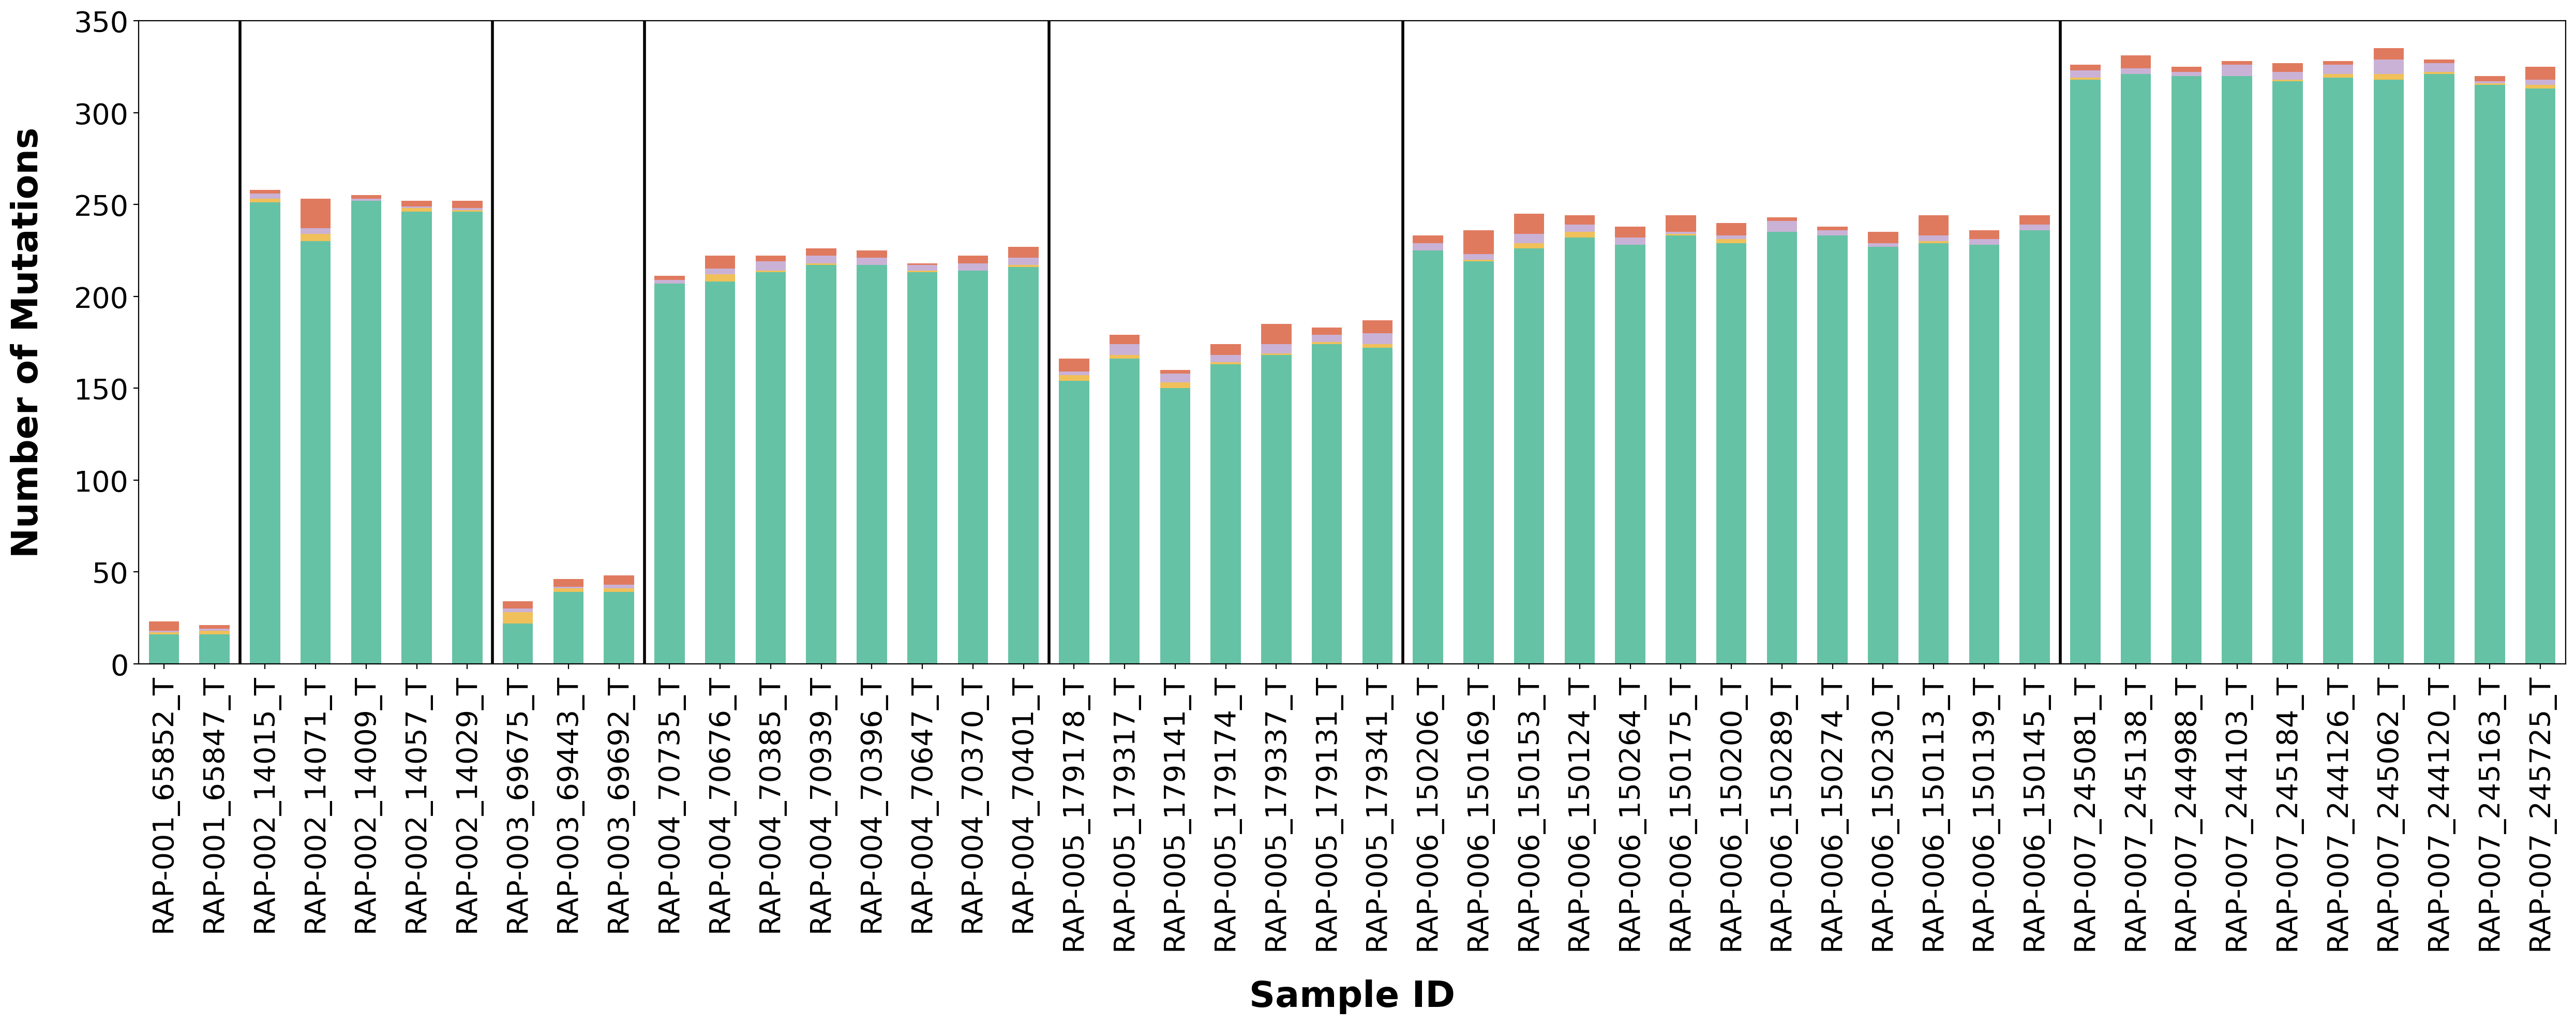

In [ ]:
color_shared_intra = "#66C2A5"  # teal
color_shared_inter = "#F0C05A"  # gold
color_both         = "#CAB2D6"  # lavender
color_unique       = "#E07A5F"  # red

# Extract sample names and percentages for each category
samples = list(plot_per_sample_var_total_dict.keys())
shared_intra = [plot_per_sample_var_total_dict[s]['shared_intra'] for s in samples]
shared_inter = [plot_per_sample_var_total_dict[s]['shared_inter'] for s in samples]
both         = [plot_per_sample_var_total_dict[s]['both'] for s in samples]
unique       = [plot_per_sample_var_total_dict[s]['unique'] for s in samples]

x = np.arange(len(samples))
bar_width = 0.6
padding = 0.2

plt.figure(figsize=(25, 10), dpi=200)

# Plot stacked bars
bars_intra = plt.bar(x, shared_intra, bar_width, label='Shared w/ Samples from the Same Patient', color=color_shared_intra)
bars_inter = plt.bar(x, shared_inter, bar_width, bottom=shared_intra, label='Shared w/ Samples from Different Patients', color=color_shared_inter)
bars_both = plt.bar(x, both, bar_width,
                    bottom=np.array(shared_intra) + np.array(shared_inter),
                    label='Shared w/ Samples from Both the Same and Different Patients', color=color_both)
bars_unique = plt.bar(x, unique, bar_width,
                      bottom=np.array(shared_intra) + np.array(shared_inter) + np.array(both),
                      label='Unique Mutations', color=color_unique)

plt.xlabel('Sample ID', fontsize=25, fontweight='bold', labelpad=20)
plt.ylabel('Number of Mutations', fontsize=25, fontweight='bold', labelpad=20)

plt.xticks(x, samples, rotation=90, ha='center', fontsize=20)
plt.yticks(fontsize=20)

left_limit = x[0] - bar_width / 2 - padding
right_limit = x[-1] + bar_width / 2 + padding
plt.xlim(left_limit, right_limit)
plt.ylim(0, 350)

# Draw vertical lines at specified positions, separating patients
split_positions = [2, 7, 10, 18, 25, 38]
for bar_index in split_positions:
    line_x = bar_index - 0.5
    plt.axvline(x=line_x, color='black', linestyle='-', linewidth=2)

plt.tight_layout()

plt.savefig('out_dir/shared_status_count.png', dpi=200)

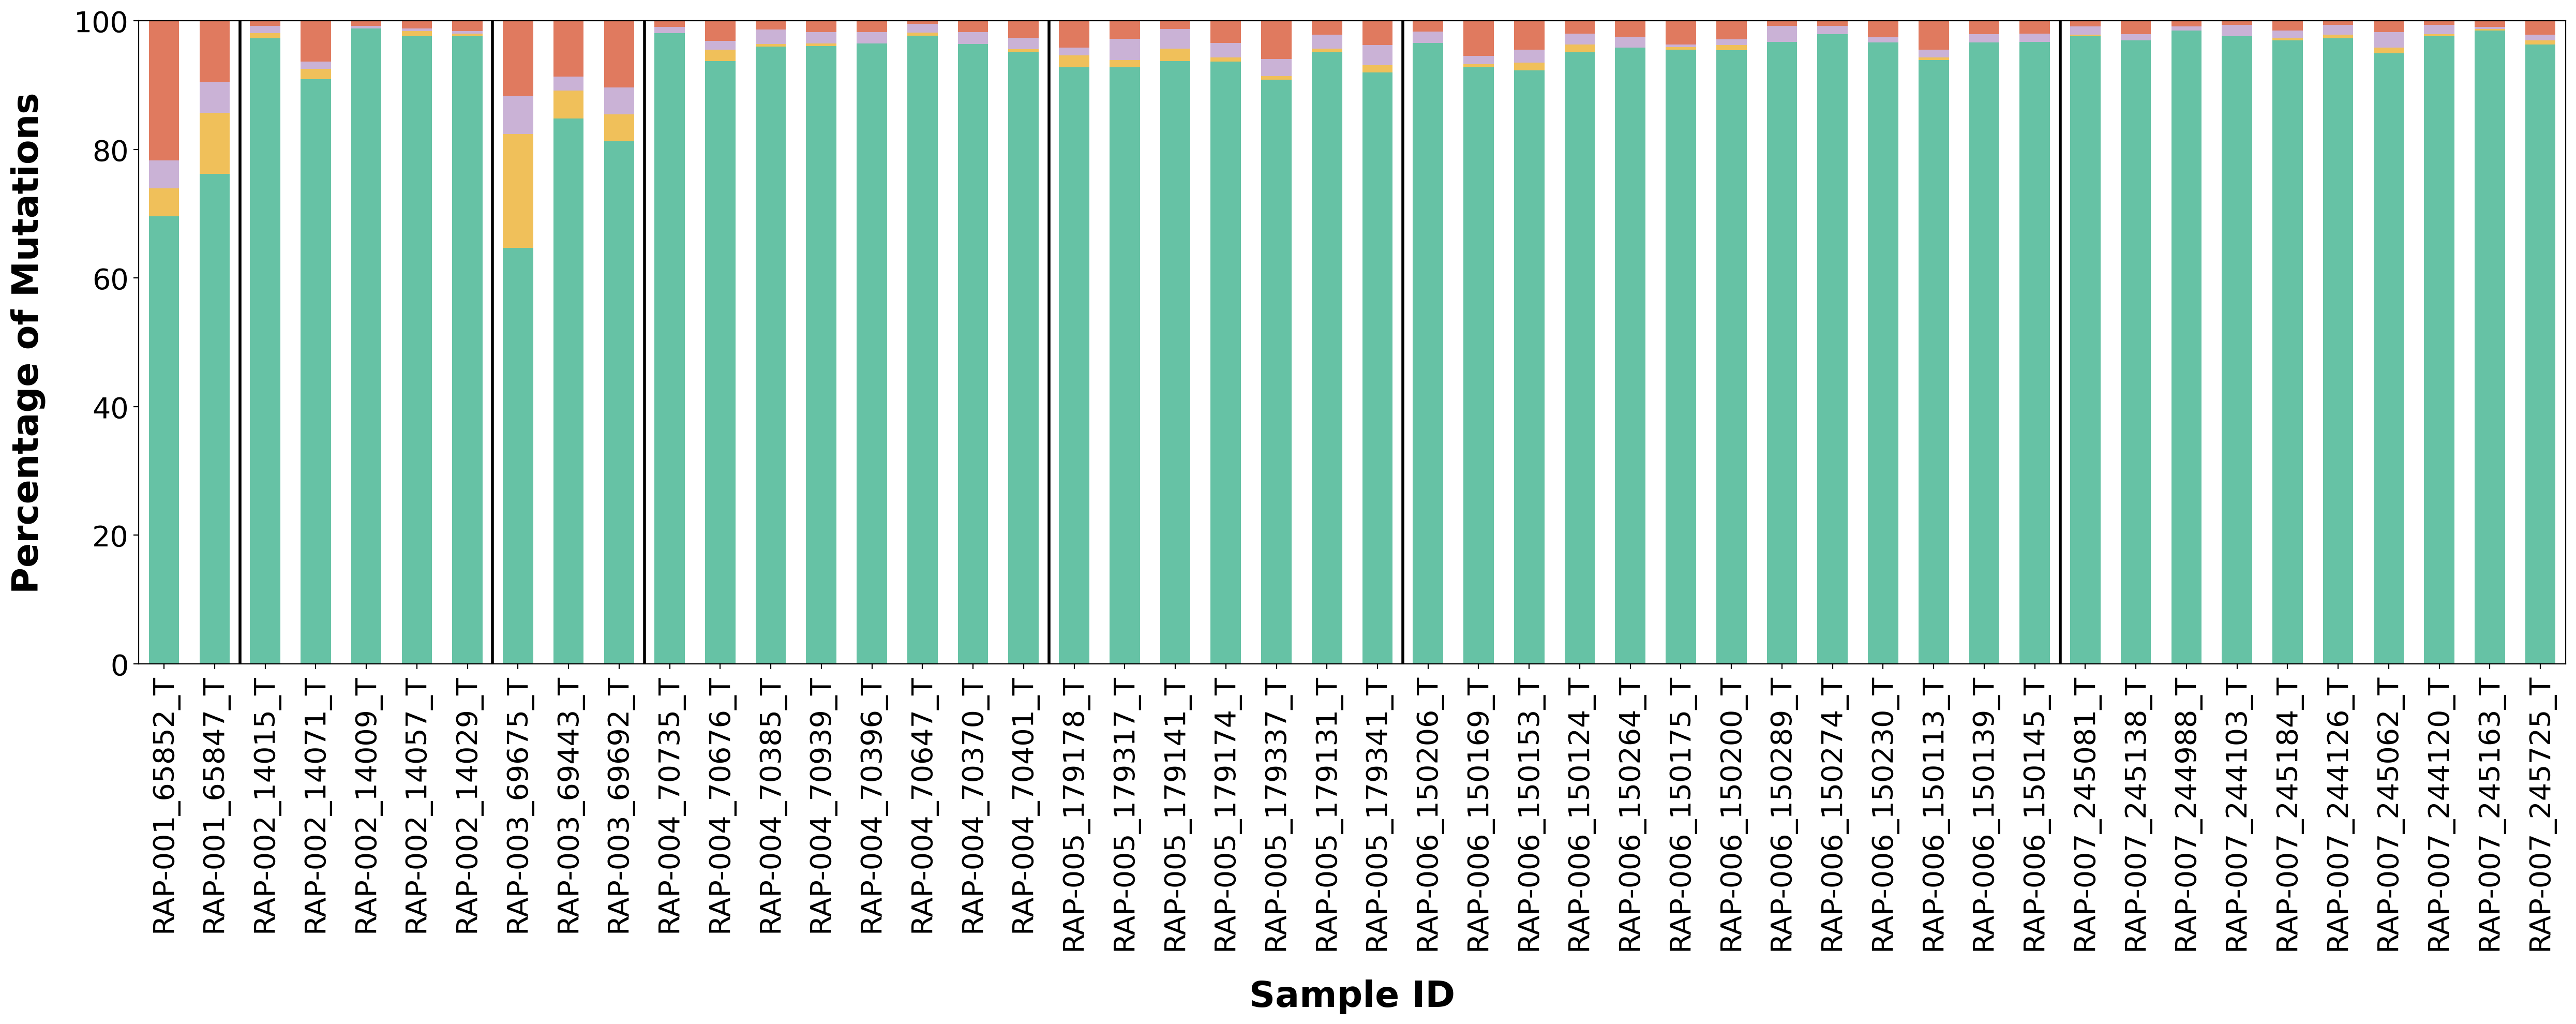

In [ ]:
color_shared_intra = "#66C2A5"  # teal
color_shared_inter = "#F0C05A"  # gold
color_both         = "#CAB2D6"  # lavender
color_unique       = "#E07A5F"  # red

# Extract sample names and percentages for each category
samples = list(plot_per_sample_var_perc_dict.keys())
shared_intra = [plot_per_sample_var_perc_dict[s]['shared_intra'] for s in samples]
shared_inter = [plot_per_sample_var_perc_dict[s]['shared_inter'] for s in samples]
both         = [plot_per_sample_var_perc_dict[s]['both'] for s in samples]
unique       = [plot_per_sample_var_perc_dict[s]['unique'] for s in samples]

x = np.arange(len(samples))
bar_width = 0.6
padding = 0.2

plt.figure(figsize=(25, 10), dpi=200)

# Plot stacked bars
bars_intra = plt.bar(x, shared_intra, bar_width, label='Shared w/ Samples from the Same Patient', color=color_shared_intra)
bars_inter = plt.bar(x, shared_inter, bar_width, bottom=shared_intra, label='Shared w/ Samples from Different Patients', color=color_shared_inter)
bars_both = plt.bar(x, both, bar_width,
                    bottom=np.array(shared_intra) + np.array(shared_inter),
                    label='Shared w/ Samples from Both the Same and Different Patients', color=color_both)
bars_unique = plt.bar(x, unique, bar_width,
                      bottom=np.array(shared_intra) + np.array(shared_inter) + np.array(both),
                      label='Unique Mutations', color=color_unique)

plt.xlabel('Sample ID', fontsize=25, fontweight='bold', labelpad=20)
plt.ylabel('Percentage of Mutations', fontsize=25, fontweight='bold', labelpad=20)

plt.xticks(x, samples, rotation=90, ha='center', fontsize=20)
plt.yticks(fontsize=20)

left_limit = x[0] - bar_width / 2 - padding
right_limit = x[-1] + bar_width / 2 + padding
plt.xlim(left_limit, right_limit)
plt.ylim(0, 100)

# Draw vertical lines at specified positions, separating patients
split_positions = [2, 7, 10, 18, 25, 38]
for bar_index in split_positions:
    line_x = bar_index - 0.5
    plt.axvline(x=line_x, color='black', linestyle='-', linewidth=2)

plt.tight_layout()

plt.savefig('out_dir/shared_status_perc.png', dpi=200)

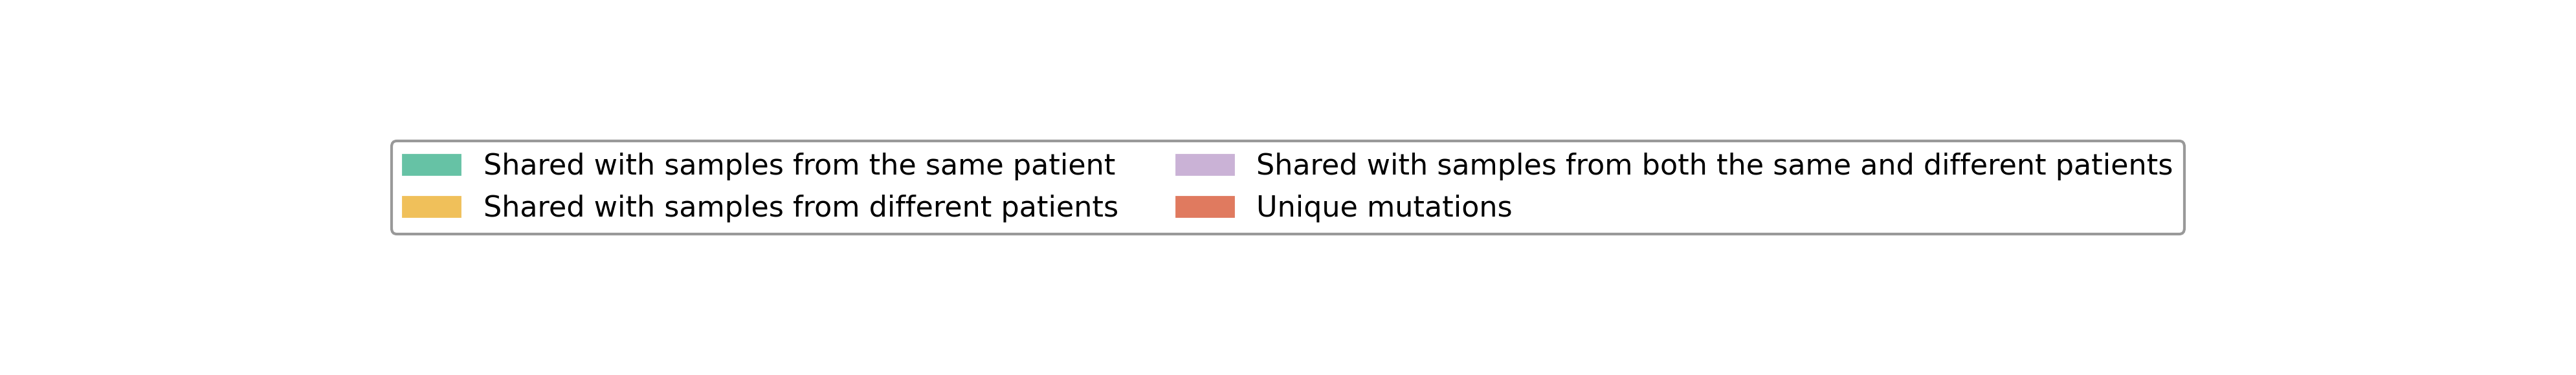

In [ ]:
color_shared_intra = "#66C2A5" 
color_shared_inter = "#F0C05A" 
color_both         = "#CAB2D6" 
color_unique       = "#E07A5F"  

# Create dummy patches with category names
patch_A = Patch(color=color_shared_intra, label='Shared with samples from the same patient')
patch_B = Patch(color=color_both, label='Shared with samples from both the same and different patients')
patch_C = Patch(color=color_shared_inter, label='Shared with samples from different patients')
patch_D = Patch(color=color_unique, label='Unique mutations')

custom_handles = [patch_A, patch_C, patch_B, patch_D]
custom_labels = [h.get_label() for h in custom_handles]

# Create a new figure for the legend only
fig_legend = plt.figure(figsize=(20, 3), dpi=200)
ax_legend = fig_legend.add_subplot(111)
ax_legend.axis('off')  # Hide axes

# Create the legend in the center with two columns and a box
legend = ax_legend.legend(custom_handles, custom_labels, loc='center', ncol=2, 
                          frameon=True, fontsize=16)
legend.get_frame().set_edgecolor('gray')
legend.get_frame().set_linewidth(1.5)

plt.tight_layout()

plt.savefig('out_dir/shared_status_legend', dpi=200)

# Plotting 2 (mutation types)

In [29]:
all_var_types = \
{"3'Flank",
 "3'UTR",
 "5'Flank",
 "5'UTR",
 'Frame_Shift_Del',
 'Frame_Shift_Ins',
 'IGR',
 'In_Frame_Del',
 'In_Frame_Ins',
 'Intron',
 'Missense_Mutation',
 'Nonsense_Mutation',
 'RNA',
 'Silent',
 'Splice_Region',
 'Splice_Site',
 'Targeted_Region',
 'Translation_Start_Site'}

selected_var_types = \
{'Frame_Shift_Del',
 'Frame_Shift_Ins',
 'In_Frame_Del',
 'In_Frame_Ins',
 'Missense_Mutation',
 'Nonsense_Mutation',
 'Splice_Site',
 'Translation_Start_Site'}

In [30]:
per_sample_var_type_count_dict = {}

for df_name in oncokb_annotated_dfs:

    temp_df = oncokb_annotated_dfs[df_name].copy()
    
    temp_dict = {i: 0 for i in selected_var_types}
    
    for _, row in temp_df.iterrows():
        
        if str(row['Variant_Classification']) in selected_var_types:        
        
            temp_dict[str(row['Variant_Classification'])] += 1
    
    per_sample_var_type_count_dict[df_name] = temp_dict.copy()

In [32]:
plot_per_sample_var_type_count_dict = {}

for sample_id in per_sample_var_type_count_dict:
    
    temp_dict = {'Nonsense': per_sample_var_type_count_dict[sample_id]['Nonsense_Mutation'], \
                 'Missense': per_sample_var_type_count_dict[sample_id]['Missense_Mutation'], \
                 'Frameshift indel': per_sample_var_type_count_dict[sample_id]['Frame_Shift_Del'] + per_sample_var_type_count_dict[sample_id]['Frame_Shift_Ins'], \
                 'In-frame indel': per_sample_var_type_count_dict[sample_id]['In_Frame_Del'] + per_sample_var_type_count_dict[sample_id]['In_Frame_Ins'], \
                 'Splice site': per_sample_var_type_count_dict[sample_id]['Splice_Site'], \
                 'Translation start site': per_sample_var_type_count_dict[sample_id]['Translation_Start_Site'], \
                 'TOTAL': 0}
    
    temp_dict['TOTAL'] =  sum(temp_dict.values())

    
    plot_per_sample_var_type_count_dict[sample_id] = temp_dict.copy()

In [34]:
plot_per_sample_var_type_perc_dict = {}

for s_id in plot_per_sample_var_type_count_dict:
    
    temp_dict = plot_per_sample_var_type_count_dict[s_id]
    
    plot_per_sample_var_type_perc_dict[s_id] =  {'Nonsense': 100 * temp_dict['Nonsense']/temp_dict['TOTAL'], \
                                                 'Missense': 100 * temp_dict['Missense']/temp_dict['TOTAL'], \
                                                 'Frameshift indel': 100 * temp_dict['Frameshift indel']/temp_dict['TOTAL'], \
                                                 'In-frame indel': 100 * temp_dict['In-frame indel']/temp_dict['TOTAL'], \
                                                 'Splice site': 100 * temp_dict['Splice site']/temp_dict['TOTAL'],\
                                                 'Translation start site': 100 * temp_dict['Translation start site']/temp_dict['TOTAL']}

In [35]:
plot_per_sample_var_type_perc_dict

{'RAP-001_65847_T': {'Nonsense': 9.523809523809524,
  'Missense': 76.19047619047619,
  'Frameshift indel': 4.761904761904762,
  'In-frame indel': 4.761904761904762,
  'Splice site': 4.761904761904762,
  'Translation start site': 0.0},
 'RAP-001_65852_T': {'Nonsense': 13.043478260869565,
  'Missense': 82.6086956521739,
  'Frameshift indel': 4.3478260869565215,
  'In-frame indel': 0.0,
  'Splice site': 0.0,
  'Translation start site': 0.0},
 'RAP-002_14009_T': {'Nonsense': 1.5686274509803921,
  'Missense': 95.68627450980392,
  'Frameshift indel': 1.5686274509803921,
  'In-frame indel': 0.0,
  'Splice site': 1.1764705882352942,
  'Translation start site': 0.0},
 'RAP-002_14015_T': {'Nonsense': 1.937984496124031,
  'Missense': 95.34883720930233,
  'Frameshift indel': 1.550387596899225,
  'In-frame indel': 0.0,
  'Splice site': 1.1627906976744187,
  'Translation start site': 0.0},
 'RAP-002_14029_T': {'Nonsense': 1.5873015873015872,
  'Missense': 94.84126984126983,
  'Frameshift indel': 1.9

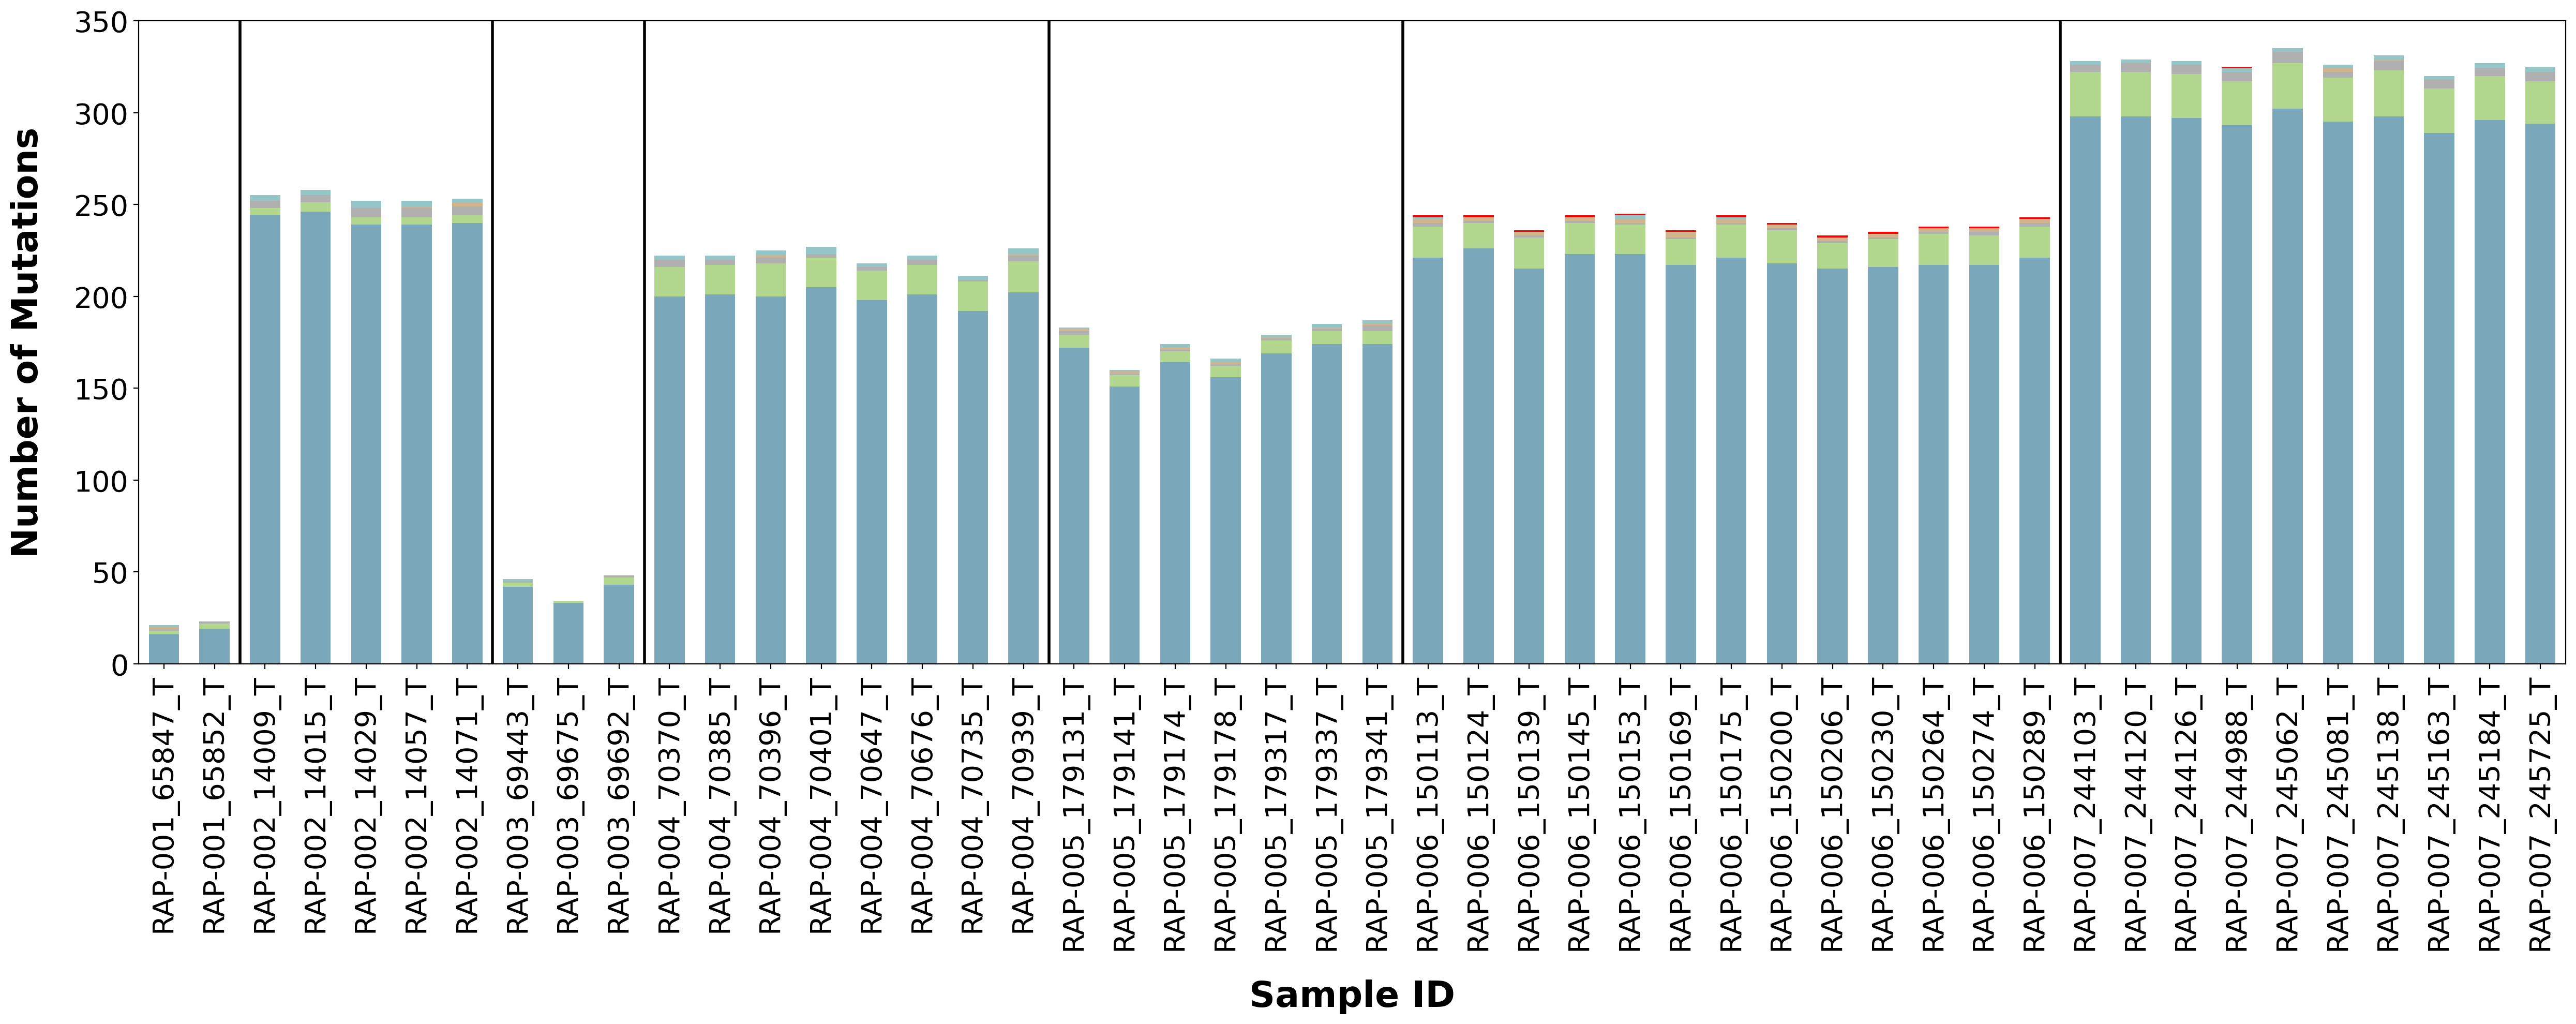

In [ ]:
# Color palette
color_missense    = "#7AA7B9"  # slate blue
color_nonsense    = "#B2D78F"  # light green
color_frameshift  = "#B0B0B0"  # gray
color_inframe     = "#D2B48C"  # tan
color_splice      = "#94C6C8"  # light blue
color_translation = "#FF0000"  # red

# Extract sample names and counts for each variant type
samples = list(plot_per_sample_var_type_count_dict.keys())
missense    = [plot_per_sample_var_type_count_dict[s]['Missense'] for s in samples]
nonsense    = [plot_per_sample_var_type_count_dict[s]['Nonsense'] for s in samples]
frameshift  = [plot_per_sample_var_type_count_dict[s]['Frameshift indel'] for s in samples]
inframe     = [plot_per_sample_var_type_count_dict[s]['In-frame indel'] for s in samples]
splice      = [plot_per_sample_var_type_count_dict[s]['Splice site'] for s in samples]
translation = [plot_per_sample_var_type_count_dict[s]['Translation start site'] for s in samples]

x = np.arange(len(samples))
bar_width = 0.6
padding = 0.2

plt.figure(figsize=(25, 10), dpi=200)

# Plot stacked bars (order from bottom to top)
bars_missense = plt.bar(x, missense, bar_width, label='Missense', color=color_missense)
bars_nonsense = plt.bar(x, nonsense, bar_width, 
                        bottom=missense, label='Nonsense', color=color_nonsense)
bars_frameshift = plt.bar(x, frameshift, bar_width, 
                          bottom=np.array(missense) + np.array(nonsense),
                          label='Frameshift indel', color=color_frameshift)
bars_inframe = plt.bar(x, inframe, bar_width, 
                       bottom=np.array(missense) + np.array(nonsense) + np.array(frameshift),
                       label='In-frame indel', color=color_inframe)
bars_splice = plt.bar(x, splice, bar_width, 
                      bottom=np.array(missense) + np.array(nonsense) + np.array(frameshift) + np.array(inframe),
                      label='Splice site', color=color_splice)
bars_translation = plt.bar(x, translation, bar_width, 
                           bottom=np.array(missense) + np.array(nonsense) + np.array(frameshift) + np.array(inframe) + np.array(splice),
                           label='Translation start site', color=color_translation)

plt.xlabel('Sample ID', fontsize=25, fontweight='bold', labelpad=20)
plt.ylabel('Number of Mutations', fontsize=25, fontweight='bold', labelpad=20)
plt.xticks(x, samples, rotation=90, ha='center', fontsize=20)
plt.yticks(fontsize=20)

left_limit = x[0] - bar_width / 2 - padding
right_limit = x[-1] + bar_width / 2 + padding
plt.xlim(left_limit, right_limit)
plt.ylim(0, 350)

split_positions = [2, 7, 10, 18, 25, 38]
for bar_index in split_positions:
    line_x = bar_index - 0.5
    plt.axvline(x=line_x, color='black', linestyle='-', linewidth=2)

plt.tight_layout()

plt.savefig('out_dir/mutation_type_count.png', dpi=200)

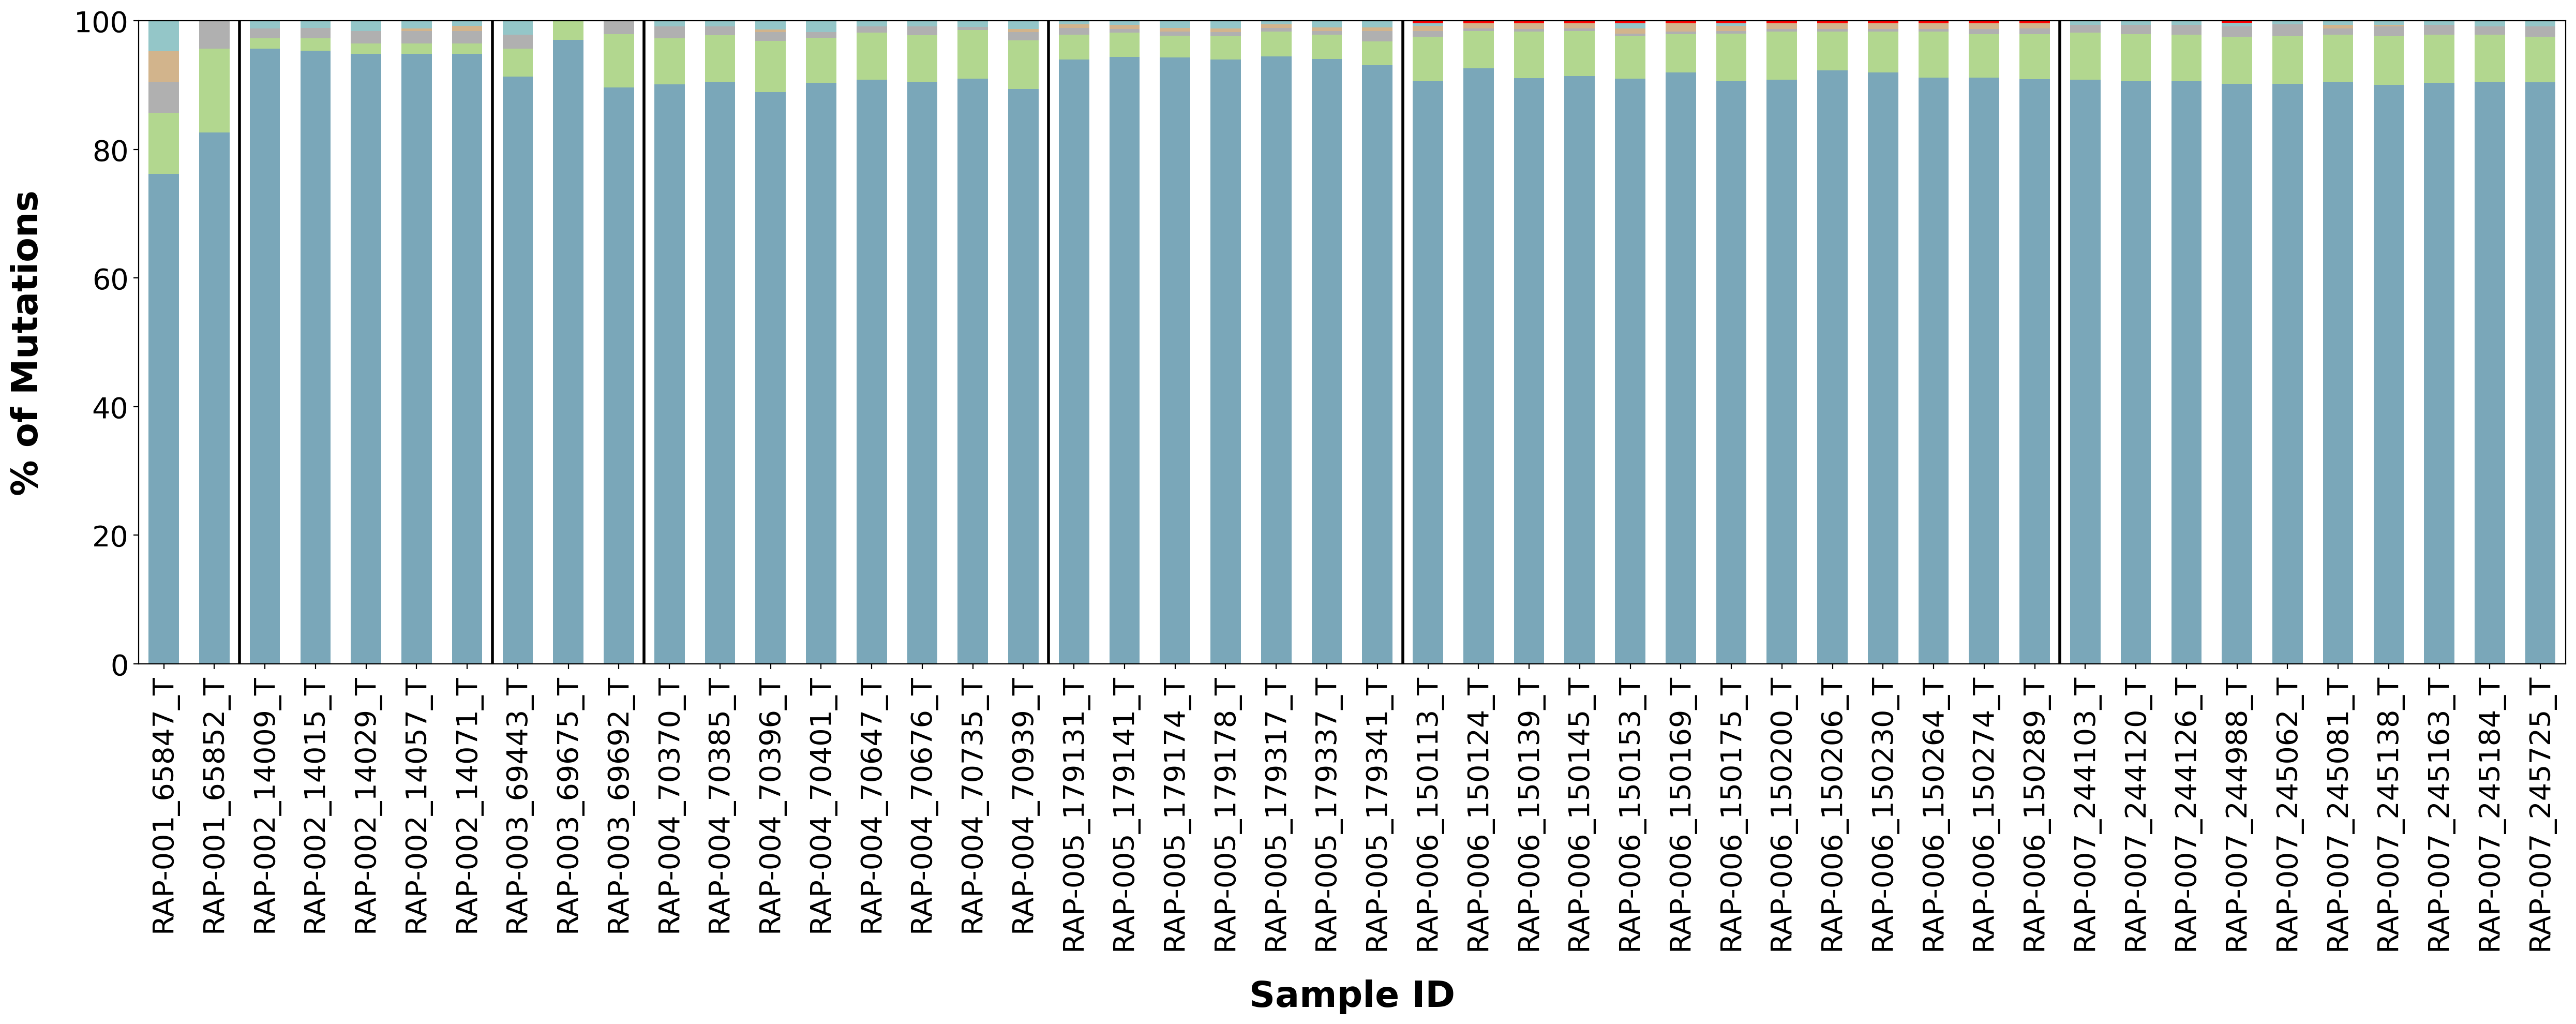

In [ ]:
# Color palette
color_missense    = "#7AA7B9"  # slate blue
color_nonsense    = "#B2D78F"  # light green
color_frameshift  = "#B0B0B0"  # gray
color_inframe     = "#D2B48C"  # tan
color_splice      = "#94C6C8"  # light blue
color_translation = "#FF0000"  # red

# Extract sample names and percentages for each variant type
samples = list(plot_per_sample_var_type_perc_dict.keys())
missense    = [plot_per_sample_var_type_perc_dict[s]['Missense'] for s in samples]
nonsense    = [plot_per_sample_var_type_perc_dict[s]['Nonsense'] for s in samples]
frameshift  = [plot_per_sample_var_type_perc_dict[s]['Frameshift indel'] for s in samples]
inframe     = [plot_per_sample_var_type_perc_dict[s]['In-frame indel'] for s in samples]
splice      = [plot_per_sample_var_type_perc_dict[s]['Splice site'] for s in samples]
translation = [plot_per_sample_var_type_perc_dict[s]['Translation start site'] for s in samples]

x = np.arange(len(samples))
bar_width = 0.6
padding = 0.2

plt.figure(figsize=(25, 10), dpi=200)

# Plot stacked bars (order from bottom to top)
bars_missense = plt.bar(x, missense, bar_width, label='Missense', color=color_missense)
bars_nonsense = plt.bar(x, nonsense, bar_width, 
                        bottom=missense, label='Nonsense', color=color_nonsense)
bars_frameshift = plt.bar(x, frameshift, bar_width, 
                          bottom=np.array(missense) + np.array(nonsense),
                          label='Frameshift indel', color=color_frameshift)
bars_inframe = plt.bar(x, inframe, bar_width, 
                       bottom=np.array(missense) + np.array(nonsense) + np.array(frameshift),
                       label='In-frame indel', color=color_inframe)
bars_splice = plt.bar(x, splice, bar_width, 
                      bottom=np.array(missense) + np.array(nonsense) + np.array(frameshift) + np.array(inframe),
                      label='Splice site', color=color_splice)
bars_translation = plt.bar(x, translation, bar_width, 
                           bottom=np.array(missense) + np.array(nonsense) + np.array(frameshift) + np.array(inframe) + np.array(splice),
                           label='Translation start site', color=color_translation)

plt.xlabel('Sample ID', fontsize=25, fontweight='bold', labelpad=20)
plt.ylabel('% of Mutations', fontsize=25, fontweight='bold', labelpad=20)
plt.xticks(x, samples, rotation=90, ha='center', fontsize=20)
plt.yticks(fontsize=20)

left_limit = x[0] - bar_width / 2 - padding
right_limit = x[-1] + bar_width / 2 + padding
plt.xlim(left_limit, right_limit)
plt.ylim(0, 100)

split_positions = [2, 7, 10, 18, 25, 38]
for bar_index in split_positions:
    line_x = bar_index - 0.5
    plt.axvline(x=line_x, color='black', linestyle='-', linewidth=2)

plt.tight_layout()

plt.savefig('out_dir/mutation_type_perc.png', dpi=200)

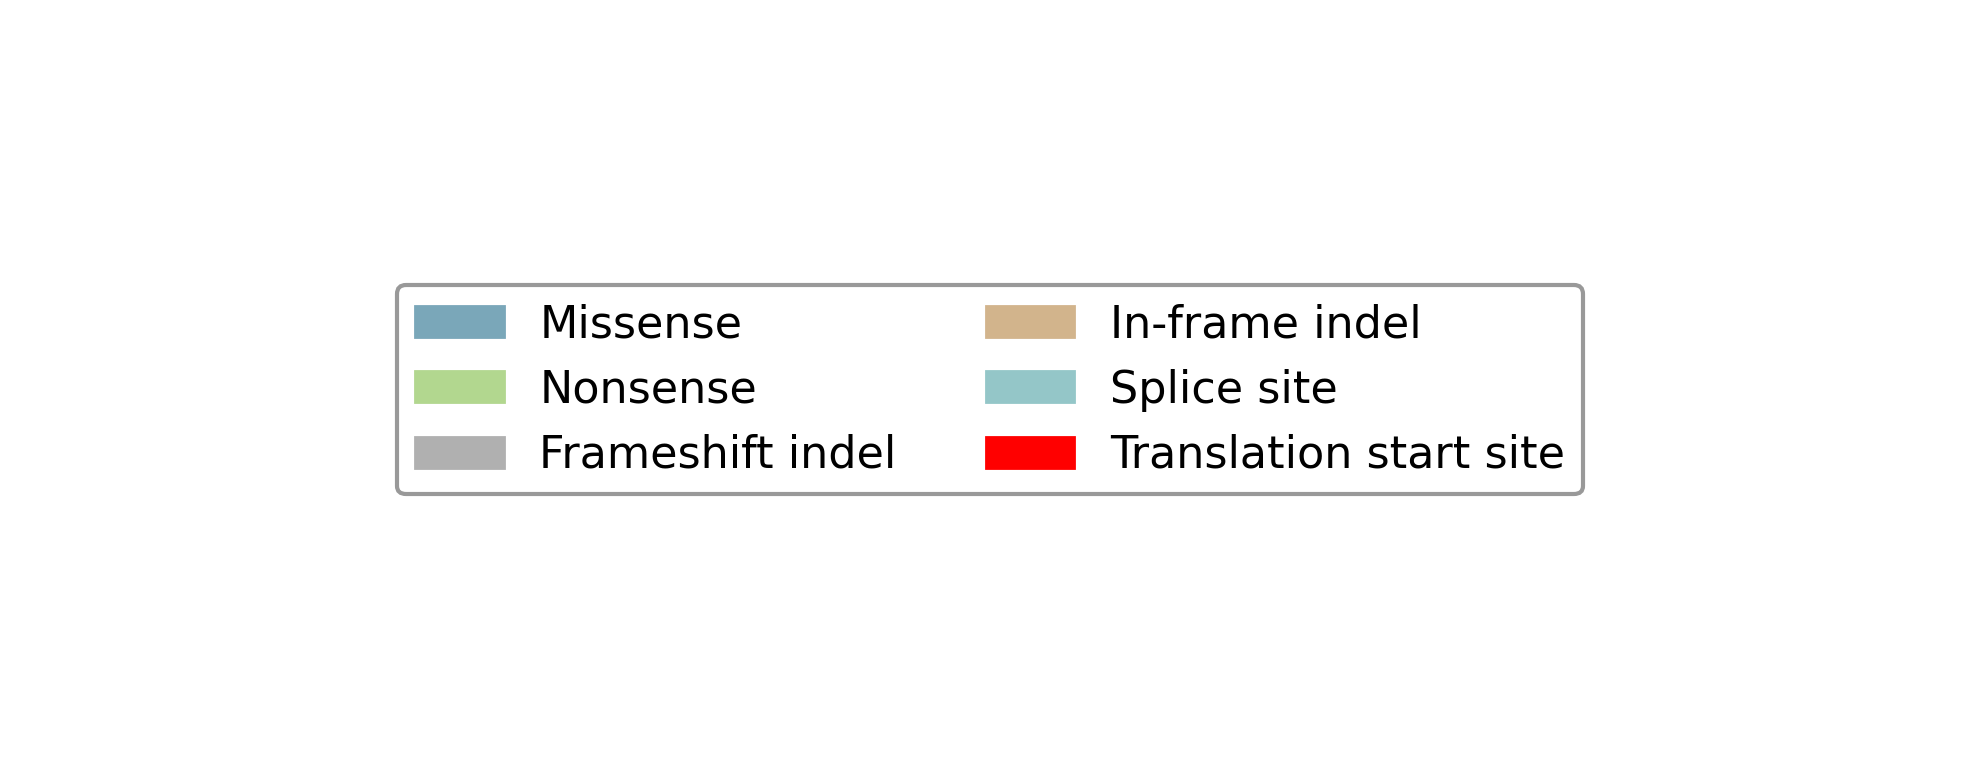

In [ ]:
# Color palette
color_missense    = "#7AA7B9"  # slate blue
color_nonsense    = "#B2D78F"  # light green
color_frameshift  = "#B0B0B0"  # gray
color_inframe     = "#D2B48C"  # tan
color_splice      = "#94C6C8"  # light blue
color_translation = "#FF0000"  # red

# Create dummy patches for each category
patch_missense    = Patch(color=color_missense, label='Missense')
patch_nonsense    = Patch(color=color_nonsense, label='Nonsense')
patch_frameshift  = Patch(color=color_frameshift, label='Frameshift indel')
patch_inframe     = Patch(color=color_inframe, label='In-frame indel')
patch_splice      = Patch(color=color_splice, label='Splice site')
patch_translation = Patch(color=color_translation, label='Translation start site')

custom_handles = [
    patch_missense, 
    patch_nonsense, 
    patch_frameshift,
    patch_inframe,
    patch_splice, 
    patch_translation
]

# Create a new figure for the legend only
fig_legend, ax_legend = plt.subplots(figsize=(10, 4), dpi=200)
ax_legend.axis('off')  # Hide the axes

legend = ax_legend.legend(
    custom_handles,
    [h.get_label() for h in custom_handles],
    loc='center',
    ncol=2,
    frameon=True,
    fontsize=16
)
legend.get_frame().set_edgecolor('gray')
legend.get_frame().set_linewidth(1.5)

plt.tight_layout()

plt.savefig('out_dir/mutation_type_legend.png', dpi=200)